In [1]:
### Parte A:

In [2]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm 

from scipy.stats import ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

In [3]:
# Del tp anterior, importamos la base construida para lo pedido en ella.

In [4]:
os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\TP3")

In [5]:
ocupados = pd.read_csv("ocupados.csv")

In [6]:
ocupados

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH14,CH15_COD,...,PP07H,informal,EMPLEO,edad2,CH12,CH13,educ,ingreso_total_familiar,horastrab,ix_tot
0,1.0,39.0,1.0,4.0,4.0,1.0,0.0,1.391111e+05,NaN,NaN,...,0.0,0,2.0,1521.0,4.0,1.0,NaN,1252000.0,NaN,9
1,1.0,35.0,5.0,1.0,6.0,1.0,0.0,2.500000e+06,NaN,NaN,...,2.0,1,2.0,1225.0,7.0,1.0,17.0,2500000.0,48.0,1
2,2.0,46.0,3.0,1.0,6.0,1.0,0.0,1.133333e+06,NaN,NaN,...,1.0,0,1.0,2116.0,7.0,1.0,17.0,3400000.0,45.0,3
3,1.0,38.0,2.0,1.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,1.0,0,1.0,1444.0,4.0,2.0,NaN,0.0,44.0,10
4,2.0,42.0,2.0,4.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,2.0,1,2.0,1764.0,4.0,2.0,NaN,0.0,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3877,1.0,53.0,5.0,1.0,2.0,1.0,0.0,3.800000e+02,NaN,NaN,...,1.0,0,NaN,2809.0,2.0,1.0,6.0,1081905.6,NaN,3
3878,1.0,52.0,2.0,4.0,2.0,1.0,0.0,1.533333e+02,NaN,NaN,...,2.0,1,NaN,2704.0,2.0,1.0,6.0,436558.4,114.0,3
3879,2.0,38.0,3.0,12.0,6.0,1.0,0.0,2.500000e+02,NaN,NaN,...,1.0,0,NaN,1444.0,6.0,1.0,15.0,474520.0,49.0,2
3880,1.0,28.0,2.0,4.0,2.0,1.0,0.0,1.250000e+02,NaN,NaN,...,0.0,0,NaN,784.0,2.0,1.0,6.0,711780.0,4.0,6


In [7]:
# Dado a que evidentemente la variable educ está teniendo problemas por la diferencia de escalas entre las bases
# del tp2, vamos a construir de vuelta esta variable cosa que no tenga tantos missing values como para poder trabajar

In [8]:
# Reconstruir educ en la base ocupados
ocupados['educ'] = np.nan

# Jardín / preescolar
ocupados.loc[ocupados['CH12'] == 1, 'educ'] = 0

# Primario
ocupados.loc[(ocupados['CH12'] == 2) & (ocupados['CH13'] == 2), 'educ'] = ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 2) & (ocupados['CH13'] == 1), 'educ'] = 6

# EGB
ocupados.loc[(ocupados['CH12'] == 3) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 3) & (ocupados['CH13'] == 1), 'educ'] = 9

# Secundario
ocupados.loc[(ocupados['CH12'] == 4) & (ocupados['CH13'] == 2), 'educ'] = 6 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 4) & (ocupados['CH13'] == 1), 'educ'] = 12

# Polimodal
ocupados.loc[(ocupados['CH12'] == 5) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,3)), 'educ'] = 9 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 5) & (ocupados['CH13'] == 1), 'educ'] = 12

# Terciario
ocupados.loc[(ocupados['CH12'] == 6) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = 12 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 6) & (ocupados['CH13'] == 1), 'educ'] = 15

# Universitario
ocupados.loc[(ocupados['CH12'] == 7) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = 12 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 7) & (ocupados['CH13'] == 1), 'educ'] = 17

# Posgrado
ocupados.loc[(ocupados['CH12'] == 8) & (ocupados['CH13'] == 2) & (ocupados['CH14'].between(0,9)), 'educ'] = 17 + ocupados['CH14']
ocupados.loc[(ocupados['CH12'] == 8) & (ocupados['CH13'] == 1), 'educ'] = 19

# Educación especial → missing
ocupados.loc[ocupados['CH12'] == 9, 'educ'] = np.nan

# Verificar
print(ocupados.groupby('AÑO')['educ'].describe())

       count       mean        std  min  25%   50%   75%    max
AÑO                                                            
2005  1817.0  10.334067   4.697936  0.0  6.0  11.0  13.0  105.0
2025  2036.0  13.069253  10.589950  0.0  9.0  12.0  15.0  105.0


In [9]:
# Limpiar outliers de educ (99 y 105 son NS/NR en la EPH)
ocupados.loc[ocupados['educ'] >= 25, 'educ'] = np.nan

In [10]:
### 1)

In [11]:
ocupados_2005 = ocupados[ocupados['AÑO'] == 2005]
ocupados_2025 = ocupados[ocupados['AÑO'] == 2025]

In [12]:
### 2)

In [13]:
print("Tipo de dato:", ocupados['educ'].dtype)
print("\nNaN por año:")
print(ocupados.groupby('AÑO')['educ'].apply(lambda x: x.isna().sum()))
print("\nValores únicos (primeros 10):", ocupados['educ'].unique()[:10])
print("\nDescriptiva por año:")
print(ocupados.groupby('AÑO')['educ'].describe())

Tipo de dato: float64

NaN por año:
AÑO
2005    12
2025    42
Name: educ, dtype: int64

Valores únicos (primeros 10): [12. 17. nan  9. 15.  8.  7.  6. 10.  3.]

Descriptiva por año:
       count       mean       std  min  25%   50%   75%   max
AÑO                                                          
2005  1816.0  10.281938  4.140351  0.0  6.0  11.0  13.0  22.0
2025  2012.0  11.987575  3.756029  0.0  9.0  12.0  15.0  20.0


In [14]:
# Variables predictoras
variables_x = [
    'CH06',
    'edad2',
    'educ',
    'ingreso_total_familiar',
    'horastrab',
    'ix_tot'
]

# Lista para resultados
resultados = []

for var in variables_x:
    x2005 = ocupados_2005[var].dropna()
    x2025 = ocupados_2025[var].dropna()

    media_2005 = x2005.mean()
    media_2025 = x2025.mean()
    diferencia = media_2025 - media_2005

    t_stat, p_value = ttest_ind(x2025, x2005, equal_var=False)

    resultados.append({
        'Variable': var,
        'Media 2005': media_2005,
        'Media 2025': media_2025,
        'Diferencia': diferencia,
        'p-value': p_value
    })

tabla_medias = pd.DataFrame(resultados)
tabla_medias

,Variable,Media 2005,Media 2025,Diferencia,p-value
0,CH06,3.935722e+01,4.112123e+01,1.764006,4.196016e-05
1,edad2,1.727737e+03,1.869914e+03,142.176956,1.396393e-04
2,educ,1.028194e+01,1.198757e+01,1.705636,1.908960e-39
3,ingreso_total_familiar,1.416588e+06,1.297905e+06,-118682.845353,5.003258e-03
4,horastrab,4.363268e+01,3.796122e+01,-5.671460,1.369044e-10
5,ix_tot,4.395514e+00,3.675268e+00,-0.720246,1.915038e-32


In [15]:
### 3)

In [16]:
# Hagamos primero para la base de 2025

In [17]:
# La variable y va a estar definida por la variable que creamos en el tp anterior llamada "informal"
# El resto forma parte de las variables dependientes, es decir edad2, educ, ingreso_total_familiar, horastrab y ix_tot
# Construyamos primero eso entonces

In [18]:
# Guardemos primero las variables X relevantes solo para 2025

var_x = [
    'edad2',
    'educ',
    'ingreso_total_familiar',
    'horastrab',
    'ix_tot'
]

# Filtrar solamente las observaciones de 2025
ocupados_2025 = ocupados[ocupados['AÑO'] == 2025].copy()

# Crear la matriz X con solo esas variables
X_2025 = ocupados_2025[var_x].copy()

In [19]:
# Lo mismo vamos a hacer para 2005

# Filtrar solamente las observaciones de 2025
ocupados_2005 = ocupados[ocupados['AÑO'] == 2005].copy()

# Crear la matriz X con solo esas variables
X_2005 = ocupados_2005[var_x].copy()

In [20]:
X_2025

,edad2,educ,ingreso_total_familiar,horastrab,ix_tot
0,1521.0,12.0,1252000.0,NaN,9
1,1225.0,17.0,2500000.0,48.0,1
2,2116.0,17.0,3400000.0,45.0,3
3,1444.0,NaN,0.0,44.0,10
4,1764.0,NaN,0.0,NaN,10
...,...,...,...,...,...
2049,676.0,12.0,1745000.0,20.0,2
2050,4096.0,6.0,611306.0,35.0,3
2051,2809.0,12.0,1850000.0,40.0,2
2052,3136.0,15.0,1850000.0,NaN,2


In [21]:
X_2005

,edad2,educ,ingreso_total_familiar,horastrab,ix_tot
2054,2601.0,12.0,2372600.0,60.0,4
2055,529.0,17.0,2372600.0,NaN,4
2056,1225.0,6.0,332164.0,46.0,4
2057,1225.0,6.0,332164.0,NaN,4
2058,1764.0,6.0,1613368.0,57.0,7
...,...,...,...,...,...
3877,2809.0,6.0,1081905.6,NaN,3
3878,2704.0,6.0,436558.4,114.0,3
3879,1444.0,15.0,474520.0,49.0,2
3880,784.0,6.0,711780.0,4.0,6


In [22]:
# Ahora, guardemos también por separado la variable dependiente y:

y_2025 = ocupados_2025['informal'].copy()
y_2005= ocupados_2005['informal'].copy()

In [23]:
print(X_2025.shape)
print(y_2025.shape)

print(X_2005.shape)
print(y_2005.shape)

(2054, 5)
(2054,)
(1828, 5)
(1828,)


In [24]:
# Con esto, deberíamos poder divir las muestras entre train y test con la función dada

In [25]:
X2025_train, X2025_test, y2025_train, y2025_test = train_test_split(X_2025, y_2025, test_size=0.30, random_state=444)

In [26]:
X2005_train, X2005_test, y2005_train, y2005_test = train_test_split(X_2005, y_2005, test_size=0.30, random_state=444)

In [27]:
# Me estaría faltando agregar la constante nada más 

In [28]:
X2025_train['constante'] = 1

X2025_test['constante'] = 1

In [29]:
X2005_train['constante'] = 1

X2005_test['constante'] = 1

In [30]:
### Parte b

In [31]:
### 1) 

In [32]:
# Realicemos la regresión logistica mediante el uso de X2025_train y X2005_train

In [33]:
# Verificamos si existen nonvalues dentro de las bases de train

In [34]:
print(X2025_train.shape)
print(y2025_train.shape)
print(X2025_train.isna().sum().sum())
print(y2025_train.isna().sum())

(1437, 6)
(1437,)
799
0


In [35]:
X2025_train.isna().sum()

edad2                       0
educ                       29
ingreso_total_familiar      0
horastrab                 770
ix_tot                      0
constante                   0
dtype: int64

In [36]:
X2025_train.dtypes

edad2                     float64
educ                      float64
ingreso_total_familiar    float64
horastrab                 float64
ix_tot                      int64
constante                   int64
dtype: object

In [37]:
y2025_train.isna().sum()

np.int64(0)

In [38]:
# Eliminemos los missing values porque sino no podríamos trabajar

# Unir X e y
train_2025 = pd.concat([X2025_train, y2025_train], axis=1)

# Eliminar filas con NaN
train_2025 = train_2025.dropna()

# Separar nuevamente
X2025_train = train_2025.drop(columns=['informal'])
y2025_train = train_2025['informal']

In [39]:
# Verifiquemos de vuelta si se sacaron correctamente los missing values

print(X2025_train.shape)
print(y2025_train.shape)
print(X2025_train.isna().sum().sum())
print(y2025_train.isna().sum())

(652, 6)
(652,)
0
0


In [40]:
# Ahora si, hagamos la regresión logistica:

log_reg = LogisticRegression(penalty=None, max_iter=1000)
log_reg.fit(X2025_train, y2025_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
print(log_reg.coef_)
print(log_reg.intercept_)

[[-3.51974083e-04 -9.51401539e-02 -2.46438557e-07 -1.77652004e-02
   3.56624201e-02  8.25915339e-01]]
[0.82591534]


In [42]:
# Calculamos los odds ratio
odds_ratio = np.exp(log_reg.coef_)
print(odds_ratio)

[[0.99964809 0.90924549 0.99999975 0.98239167 1.03630595 2.28397042]]


In [43]:
# Hagamos el mismo proceso para 2005

In [44]:
# Eliminemos los missing values porque sino no podríamos trabajar

# Unir X e y
train_2005 = pd.concat([X2005_train, y2005_train], axis=1)

# Eliminar filas con NaN
train_2005 = train_2005.dropna()

# Separar nuevamente
X2005_train = train_2005.drop(columns=['informal'])
y2005_train = train_2005['informal']

In [45]:
# Ahora si, hagamos la regresión logistica:

log_reg2 = LogisticRegression(penalty=None, max_iter=1000)
log_reg2.fit(X2005_train, y2005_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
print(log_reg2.coef_)
print(log_reg2.intercept_)

[[ 9.76032678e-05 -1.60806208e-02 -1.12451613e-06 -1.08125889e-02
   1.31851119e-01  2.18437103e-02]]
[0.02184371]


In [47]:
# Calculamos los odds ratio
odds_ratio2 = np.exp(log_reg2.coef_)
print(odds_ratio2)

[[1.00009761 0.98404798 0.99999888 0.98924566 1.14093844 1.02208403]]


In [48]:
# Construyamos la tabla pedida de la misma forma que la presentada en clases

In [49]:
# Variables reales usadas en cada regresión
variables_2025 = list(X_2025.columns)
variables_2005 = list(X_2005.columns)

# Coeficientes
coef_2025 = log_reg.coef_[0]
coef_2005 = log_reg2.coef_[0]

# Interceptos
intercepto_2025 = log_reg.intercept_[0]
intercepto_2005 = log_reg2.intercept_[0]

# Odds ratios
odds_2025 = np.exp(coef_2025)
odds_2005 = np.exp(coef_2005)

odds_intercepto_2025 = np.exp(intercepto_2025)
odds_intercepto_2005 = np.exp(intercepto_2005)

# Tabla
filas = []

# Intercepto / constante
filas.append({
    "Predictor": "Constante",
    "Coeficiente 2025": intercepto_2025,
    "Odds ratio 2025": odds_intercepto_2025,
    "Coeficiente 2005": intercepto_2005,
    "Odds ratio 2005": odds_intercepto_2005
})

# Variables de X
for i, var in enumerate(variables_2025):
    filas.append({
        "Predictor": var,
        "Coeficiente 2025": coef_2025[i],
        "Odds ratio 2025": odds_2025[i],
        "Coeficiente 2005": coef_2005[i],
        "Odds ratio 2005": odds_2005[i]
    })

tabla_regresion = pd.DataFrame(filas)

tabla_regresion = tabla_regresion.round(4)

display(tabla_regresion)

,Predictor,Coeficiente 2025,Odds ratio 2025,Coeficiente 2005,Odds ratio 2005
0,Constante,0.8259,2.2840,0.0218,1.0221
1,edad2,-0.0004,0.9996,0.0001,1.0001
2,educ,-0.0951,0.9092,-0.0161,0.9840
3,ingreso_total_familiar,-0.0000,1.0000,-0.0000,1.0000
4,horastrab,-0.0178,0.9824,-0.0108,0.9892
5,ix_tot,0.0357,1.0363,0.1319,1.1409


In [50]:
### 2)

In [51]:
# Realizemos el gráfico pedido. Para el eje horizontal utilizemos educ

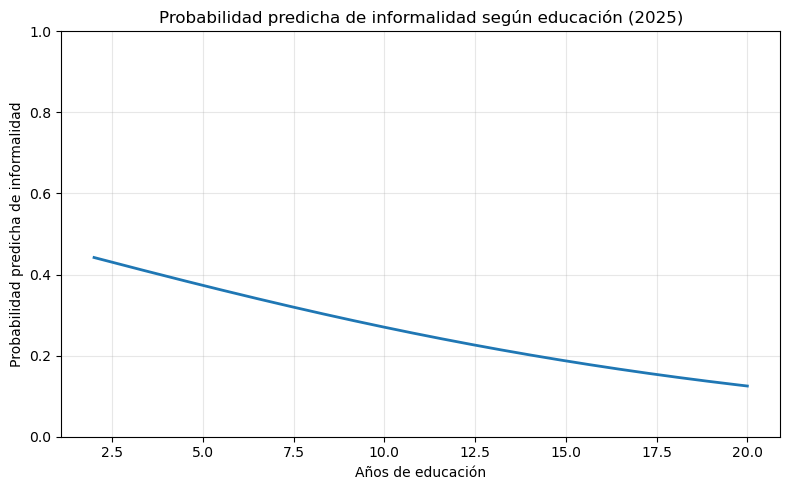

In [52]:
# Elegimos 'educ' como variable a ilustrar (podés cambiarla por CH06, horastrab, etc.)
var = 'educ'

# Base limpia para el gráfico
df_graf = X2025_train.copy()
df_graf = df_graf[df_graf['educ'].between(0, 25)]

# Valores del eje X
x_vals = np.linspace(df_graf[var].min(), df_graf[var].max(), 200)

# Promedio de las variables
x_mean = X2025_train.mean()

# Crear grilla
X_grid = pd.DataFrame(
    np.tile(x_mean.values, (len(x_vals), 1)),
    columns=X2025_train.columns
)

# Reemplazar la variable de interés
X_grid[var] = x_vals

# Probabilidades predichas
p_hat = log_reg.predict_proba(X_grid)[:, 1]

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(x_vals, p_hat, linewidth=2)

plt.xlabel('Años de educación')
plt.ylabel('Probabilidad predicha de informalidad')
plt.title('Probabilidad predicha de informalidad según educación (2025)')

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('proba_informalidad2025.png', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
# Ahora necesitamos hacer lo mismo para la base de Xtrain de 2005, haciendolo de la misma forma

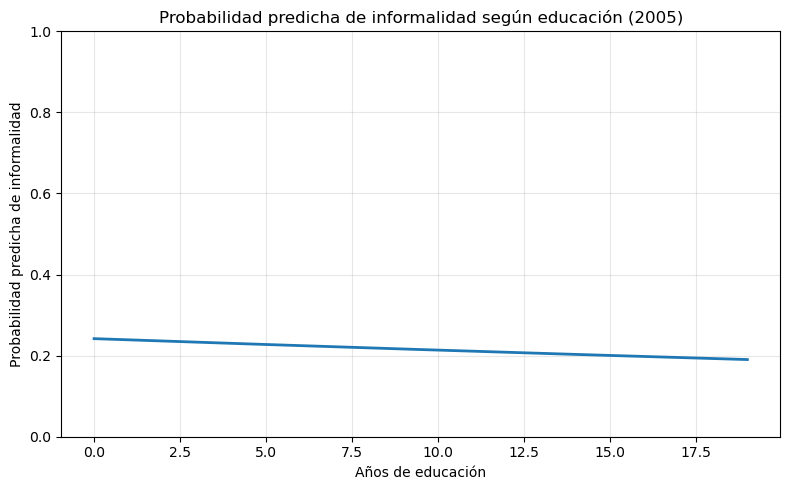

In [54]:
# Elegimos 'educ' como variable a ilustrar (podés cambiarla por CH06, horastrab, etc.)
var = 'educ'

# Base limpia para el gráfico
df_graf2 = X2005_train.copy()
df_graf2 = df_graf2[df_graf2['educ'].between(0, 25)]

# Valores del eje X
x_vals = np.linspace(df_graf2[var].min(), df_graf2[var].max(), 200)

# Promedio de las variables
x_mean = X2005_train.mean()

# Crear grilla
X_grid = pd.DataFrame(
    np.tile(x_mean.values, (len(x_vals), 1)),
    columns=X2005_train.columns
)

# Reemplazar la variable de interés
X_grid[var] = x_vals

# Probabilidades predichas
p_hat = log_reg2.predict_proba(X_grid)[:, 1]

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(x_vals, p_hat, linewidth=2)

plt.xlabel('Años de educación')
plt.ylabel('Probabilidad predicha de informalidad')
plt.title('Probabilidad predicha de informalidad según educación (2005)')

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('proba_informalidad2005.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
### C. Método de Vecinos Cercanos (KNN)

In [56]:
### 3)

In [57]:
# Hagamos primero para 2025 la estimación de vecinos cercanos utilizando los k pedidos:

In [58]:
X2025_train.isna().sum()
X2025_test.isna().sum()

edad2                       0
educ                       13
ingreso_total_familiar      0
horastrab                 330
ix_tot                      0
constante                   0
dtype: int64

In [59]:
# Dado a que KNN no funciona al tener valores de missing values, saquemos estos para poder trabajar:

In [60]:
# Mantener solo observaciones completas en train
train_mask = X2025_train.notna().all(axis=1)
X2025_train_knn = X2025_train.loc[train_mask]
y2025_train_knn = y2025_train.loc[train_mask]

# Mantener solo observaciones completas en test
test_mask = X2025_test.notna().all(axis=1)
X2025_test_knn = X2025_test.loc[test_mask]
y2025_test_knn = y2025_test.loc[test_mask]

In [61]:
X2025_train_knn = X2025_train.drop(columns=['constante'], errors='ignore')
X2025_test_knn  = X2025_test.drop(columns=['constante'], errors='ignore')

In [62]:
print("NaN en X2025_train_knn:", X2025_train_knn.isna().sum().sum())
print("NaN en y2025_train_knn:", y2025_train_knn.isna().sum())
print("NaN en X2025_test_knn:", X2025_test_knn.isna().sum().sum())
print("NaN en y2025_test_knn:", y2025_test_knn.isna().sum())
print("Shape train:", X2025_train_knn.shape, y2025_train_knn.shape)
print("Shape test:", X2025_test_knn.shape, y2025_test_knn.shape)

NaN en X2025_train_knn: 0
NaN en y2025_train_knn: 0
NaN en X2025_test_knn: 343
NaN en y2025_test_knn: 0
Shape train: (652, 5) (652,)
Shape test: (617, 5) (277,)


In [63]:
# Limpiar test correctamente
test_2025_knn = pd.concat([X2025_test, y2025_test], axis=1).dropna()
X2025_test_knn = test_2025_knn.drop(columns=['informal', 'constante'], errors='ignore')
y2025_test_knn = test_2025_knn['informal']

# Verificar
print("NaN en X2025_test_knn:", X2025_test_knn.isna().sum().sum())  # debe dar 0
print("Shape test:", X2025_test_knn.shape, y2025_test_knn.shape)

NaN en X2025_test_knn: 0
Shape test: (277, 5) (277,)


In [64]:
k_range = [10, 50, 100]
scores_2025 = {}      # Para guardar la accuracy en un diccionario
scores_list_2025 = [] # Para guardar la accuracy en una lista
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X2025_train_knn, y2025_train_knn)
        y2025_pred = knn.predict(X2025_test_knn)
        scores_2025[k] = accuracy_score(y2025_test_knn, y2025_pred)
        scores_list_2025.append(accuracy_score(y2025_test_knn, y2025_pred))

In [65]:
scores_2025

{10: 0.7328519855595668, 50: 0.7148014440433214, 100: 0.7148014440433214}

In [66]:
# Ahora hagamoslo para 2005

In [67]:
# Mantener solo observaciones completas en train
train_mask = X2005_train.notna().all(axis=1)
X2005_train_knn = X2005_train.loc[train_mask]
y2005_train_knn = y2005_train.loc[train_mask]

# Mantener solo observaciones completas en test
test_mask = X2005_test.notna().all(axis=1)
X2005_test_knn = X2005_test.loc[test_mask]
y2005_test_knn = y2005_test.loc[test_mask]

In [68]:
X2005_train_knn = X2005_train.drop(columns=['constante'], errors='ignore')
X2005_test_knn  = X2005_test.drop(columns=['constante'], errors='ignore')

In [69]:
# Limpiar test correctamente
test_2005_knn = pd.concat([X2005_test, y2005_test], axis=1).dropna()
X2005_test_knn = test_2005_knn.drop(columns=['informal', 'constante'], errors='ignore')
y2005_test_knn = test_2005_knn['informal']

# Verificar
print("NaN en X2025_test_knn:", X2005_test_knn.isna().sum().sum())  # debe dar 0
print("Shape test:", X2005_test_knn.shape, y2005_test_knn.shape)

NaN en X2025_test_knn: 0
Shape test: (259, 5) (259,)


In [70]:
k_range = [10, 50, 100]
scores_2005 = {}      # Para guardar la accuracy en un diccionario
scores_list_2005 = [] # Para guardar la accuracy en una lista
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X2005_train_knn, y2005_train_knn)
        y2005_pred = knn.predict(X2005_test_knn)
        scores_2005[k] = accuracy_score(y2005_test_knn, y2005_pred)
        scores_list_2005.append(accuracy_score(y2005_test_knn, y2005_pred))

In [71]:
scores_2005

{10: 0.7413127413127413, 50: 0.7451737451737451, 100: 0.749034749034749}

In [72]:
### 4)

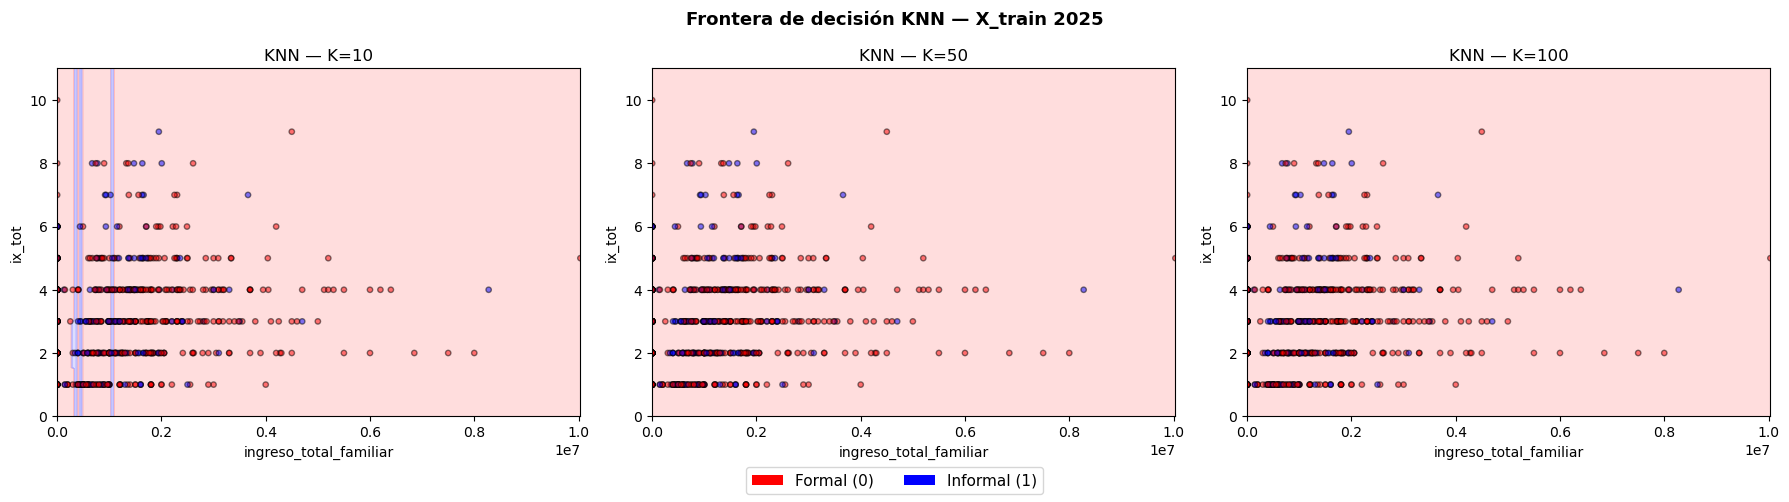

In [73]:
# Elegimos dos variables numéricas para los ejes
var1 = 'ingreso_total_familiar'
var2 = 'ix_tot'

# Usamos solo esas dos variables (sin NaN)
df_plot = pd.concat([X2025_train_knn[[var1, var2]], y2025_train_knn], axis=1).dropna()
X_plot2d = df_plot[[var1, var2]].values
y_plot2d = df_plot['informal'].values

# Grilla para el fondo
x_min, x_max = X_plot2d[:, 0].min() - 1, X_plot2d[:, 0].max() + 1
y_min, y_max = X_plot2d[:, 1].min() - 1, X_plot2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

cmap_bg  = ListedColormap(['#FFAAAA', '#AAAAFF'])  # rojo suave / azul suave
cmap_pts = ListedColormap(['red', 'blue'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, [10, 50, 100]):
    knn_plot = KNeighborsClassifier(n_neighbors=k)
    knn_plot.fit(X_plot2d, y_plot2d)
    
    Z = knn_plot.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    scatter = ax.scatter(X_plot2d[:, 0], X_plot2d[:, 1],
                         c=y_plot2d, cmap=cmap_pts,
                         edgecolors='k', s=15, alpha=0.5)
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)
    ax.set_title(f'KNN — K={k}')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red',  label='Formal (0)'),
                   Patch(facecolor='blue', label='Informal (1)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11)
plt.suptitle('Frontera de decisión KNN — X_train 2025', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('knn_frontera.png', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
### 5) 

In [75]:
# Dividamos entonces la parte de ocupados 2025 train en 5 partes como se nos pide

In [76]:
# Crear el objeto de validación cruzada en 5 partes (folds)
kf = KFold(n_splits=5, shuffle=True, random_state=444)

In [77]:
# Rango de K a evaluar
k_range = range(1, 151)   # probamos K = 1, 2, ..., 150

accuracy_cv = []   # accuracy promedio para cada K
accuracy_std = []  # desvío estándar (para la banda de error del gráfico)

X_train_arr = X2025_train.values
y_train_arr = y2025_train.values

for k in k_range:
    # Pipeline: estandarizar → KNN
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k))
    ])
    # cross_val_score hace el CV internamente
    scores = cross_val_score(pipe, X_train_arr, y_train_arr,
                             cv=kf, scoring='accuracy')
    accuracy_cv.append(scores.mean())
    accuracy_std.append(scores.std())

accuracy_cv  = np.array(accuracy_cv)
accuracy_std = np.array(accuracy_std)

# K óptimo
k_optimo = list(k_range)[np.argmax(accuracy_cv)]
acc_optimo = accuracy_cv.max()

print(f"K óptimo por CV:  K = {k_optimo}")
print(f"Accuracy CV máx.: {acc_optimo:.4f}")

K óptimo por CV:  K = 70
Accuracy CV máx.: 0.7409


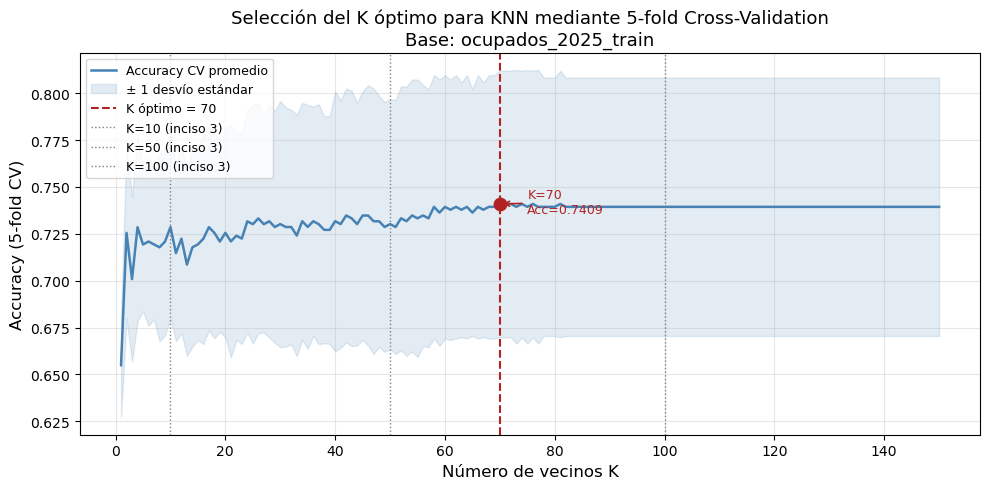

Gráfico guardado como 'knn_cv_accuracy.png'


In [78]:
# ── Gráfico Accuracy vs K ──────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# Línea principal
ax.plot(list(k_range), accuracy_cv,
        color='steelblue', linewidth=1.8, label='Accuracy CV promedio')

# Banda ± 1 desvío
ax.fill_between(list(k_range),
                accuracy_cv - accuracy_std,
                accuracy_cv + accuracy_std,
                alpha=0.15, color='steelblue', label='± 1 desvío estándar')

# Punto y línea del K óptimo
ax.axvline(x=k_optimo, color='firebrick', linestyle='--', linewidth=1.5,
           label=f'K óptimo = {k_optimo}')
ax.scatter([k_optimo], [acc_optimo],
           color='firebrick', zorder=5, s=80)
ax.annotate(f'K={k_optimo}\nAcc={acc_optimo:.4f}',
            xy=(k_optimo, acc_optimo),
            xytext=(k_optimo + 5, acc_optimo - 0.005),
            fontsize=9, color='firebrick',
            arrowprops=dict(arrowstyle='->', color='firebrick', lw=1.2))

# Líneas verticales para los K del inciso 3 (K=10, 50, 100)
for k_ref, ls in zip([10, 50, 100], [':', ':', ':']):
    ax.axvline(x=k_ref, color='gray', linestyle=ls, linewidth=1,
               label=f'K={k_ref} (inciso 3)')

ax.set_xlabel('Número de vecinos K', fontsize=12)
ax.set_ylabel('Accuracy (5-fold CV)', fontsize=12)
ax.set_title('Selección del K óptimo para KNN mediante 5-fold Cross-Validation\n'
             'Base: ocupados_2025_train', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_cv_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'knn_cv_accuracy.png'")

In [79]:
# ── Tabla resumen de los K evaluados ──────────────────────────────────────

tabla_cv = pd.DataFrame({
    'K': list(k_range),
    'Accuracy CV (promedio)': accuracy_cv.round(4),
    'Accuracy CV (std)': accuracy_std.round(4)
})

# Mostramos los 5 mejores K
print("Top 10 valores de K por Accuracy CV:")
display(tabla_cv.sort_values('Accuracy CV (promedio)', ascending=False).head(10))

Top 10 valores de K por Accuracy CV:


,K,Accuracy CV (promedio),Accuracy CV (std)
75,76,0.7409,0.0711
80,81,0.7409,0.0711
73,74,0.7409,0.0711
71,72,0.7409,0.0711
70,71,0.7409,0.0711
69,70,0.7409,0.0711
103,104,0.7394,0.0689
97,98,0.7394,0.0689
98,99,0.7394,0.0689
99,100,0.7394,0.0689


In [80]:
### D. Desempeño de modelos, elección y predicción afuera de la muestra

In [81]:
### 6)

Matriz de confusión - Logit
[[189   9]
 [ 71   8]]

Matriz de confusión - KNN con K-CV
[[197   1]
 [ 78   1]]


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Logit,0.7112,0.4706,0.1013,0.1667,0.7267
1,KNN con K-CV,0.7148,0.5000,0.0127,0.0247,0.7228


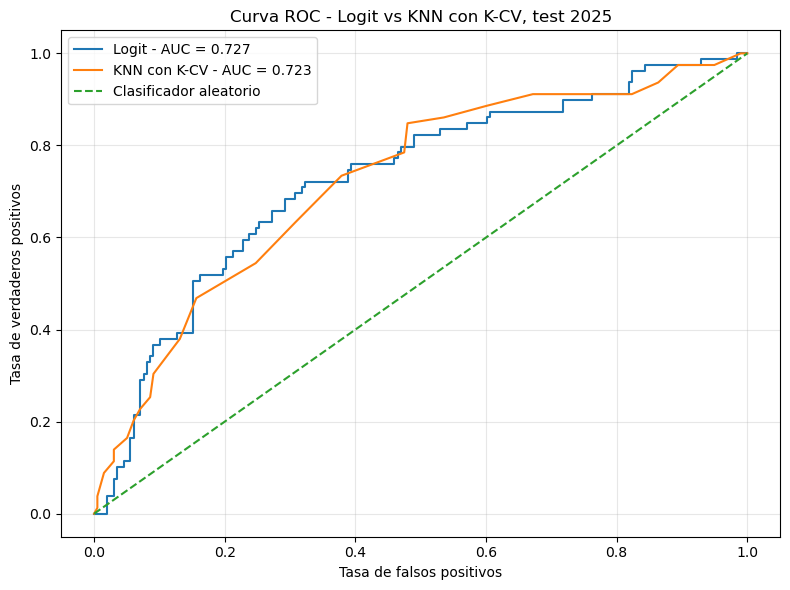

In [82]:
# Armamos una base de test 2025 limpia, usando las mismas variables de X
test_2025 = pd.concat([X2025_test, y2025_test], axis=1).dropna()

X2025_test_limpio = test_2025.drop(columns=['informal'])
y2025_test_limpio = test_2025['informal']

# ----------------------------
# 1. LOGIT
# ----------------------------

# Probabilidad predicha de informalidad
y_prob_logit = log_reg.predict_proba(X2025_test_limpio)[:, 1]

# Clasificación con umbral 0.5
y_pred_logit = (y_prob_logit > 0.5).astype(int)

# ----------------------------
# 2. KNN con K óptimo por CV
# ----------------------------

# Para KNN sacamos la constante porque no corresponde usarla
X2025_train_knn_cv = X2025_train.drop(columns=['constante'], errors='ignore')
X2025_test_knn_cv = X2025_test_limpio.drop(columns=['constante'], errors='ignore')

# Modelo KNN con el K óptimo obtenido en el inciso anterior
knn_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=k_optimo))
])

knn_cv.fit(X2025_train_knn_cv, y2025_train)

# Probabilidad predicha de informalidad
y_prob_knn = knn_cv.predict_proba(X2025_test_knn_cv)[:, 1]

# Clasificación con umbral 0.5
y_pred_knn = (y_prob_knn > 0.5).astype(int)

# ----------------------------
# 3. Matrices de confusión
# ----------------------------

print("Matriz de confusión - Logit")
print(confusion_matrix(y2025_test_limpio, y_pred_logit))

print("\nMatriz de confusión - KNN con K-CV")
print(confusion_matrix(y2025_test_limpio, y_pred_knn))

# ----------------------------
# 4. Métricas de desempeño
# ----------------------------

metricas = pd.DataFrame({
    'Modelo': ['Logit', 'KNN con K-CV'],
    'Accuracy': [
        accuracy_score(y2025_test_limpio, y_pred_logit),
        accuracy_score(y2025_test_limpio, y_pred_knn)
    ],
    'Precision': [
        precision_score(y2025_test_limpio, y_pred_logit, zero_division=0),
        precision_score(y2025_test_limpio, y_pred_knn, zero_division=0)
    ],
    'Recall': [
        recall_score(y2025_test_limpio, y_pred_logit, zero_division=0),
        recall_score(y2025_test_limpio, y_pred_knn, zero_division=0)
    ],
    'F1-score': [
        f1_score(y2025_test_limpio, y_pred_logit, zero_division=0),
        f1_score(y2025_test_limpio, y_pred_knn, zero_division=0)
    ],
    'AUC': [
        roc_auc_score(y2025_test_limpio, y_prob_logit),
        roc_auc_score(y2025_test_limpio, y_prob_knn)
    ]
})

display(metricas.round(4))

# ----------------------------
# 5. Curvas ROC
# ----------------------------

fpr_logit, tpr_logit, _ = roc_curve(y2025_test_limpio, y_prob_logit)
fpr_knn, tpr_knn, _ = roc_curve(y2025_test_limpio, y_prob_knn)

auc_logit = roc_auc_score(y2025_test_limpio, y_prob_logit)
auc_knn = roc_auc_score(y2025_test_limpio, y_prob_knn)

plt.figure(figsize=(8, 6))

plt.plot(fpr_logit, tpr_logit, label=f'Logit - AUC = {auc_logit:.3f}')
plt.plot(fpr_knn, tpr_knn, label=f'KNN con K-CV - AUC = {auc_knn:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Clasificador aleatorio')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Logit vs KNN con K-CV, test 2025')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_logit_knn_2025.png', dpi=300, bbox_inches='tight')
plt.show()